# Drafted Soldiers


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


In [50]:
df_nup = pd.read_csv("../data/intermediate/drafted.csv")
df_monthly = pd.read_csv("../data/intermediate/monthly.csv")
df_monthly.drop(columns="Unnamed: 0", inplace=True)

In [51]:
reg_name_map = {'Архангельская область':'Архангельская область без АО',
 'Еврейская автономная область':'Еврейская АО',
 'Кабардино-Балкарская Республика':'Кабардино-Балкария',
 'Карачаево-Черкесская Республика':'Карачаево-Черкесия',
 'Кемеровская область - Кузбасс': 'Кемеровская область',
 'Республика Саха (Якутия)' :  'Якутия',
 'Республика Северная Осетия-Алания' : 'Северная Осетия',
 'Тюменская область' :'Тюменская область без АО',
 'Чукотский автономный округ': 'Чукотский АО',
 'г. Москва' : 'Москва',
 'г. Санкт-Петербург' :  'Санкт-Петербург',
 'г. Севастополь' : 'Севастополь'
}


df_nup["region"] = df_nup["region"].replace(reg_name_map)
df_nup.rename(columns={'region':'Region', 'total' : 'draft_age'}, inplace=True)
df_nup = df_nup[['Region', 'mob_est', 'draft_age']]
df = df_monthly.merge(df_nup, on = 'Region', how = 'left')
df

,Region,Date,slavic_name,non_slavic_name,pmc,drafted,volunteers,prisoners,contract,total,...,position,governor,start,end,birth_year,insider,approved,nat_rep,mob_est,draft_age
0,Алтайский край,2022-02-01,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Heads of the administration/governors,Viktor Tomenko,2018-05-30,2025-08-08,1971.0,0.0,1.0,0.0,10556.20771,544795.0
1,Алтайский край,2022-03-01,33.0,2.0,0.0,0.0,0.0,0.0,35.0,35.0,...,Heads of the administration/governors,Viktor Tomenko,2018-05-30,2025-08-08,1971.0,0.0,1.0,0.0,10556.20771,544795.0
2,Алтайский край,2022-04-01,30.0,2.0,0.0,0.0,2.0,0.0,30.0,32.0,...,Heads of the administration/governors,Viktor Tomenko,2018-05-30,2025-08-08,1971.0,0.0,1.0,0.0,10556.20771,544795.0
3,Алтайский край,2022-05-01,57.0,5.0,0.0,0.0,2.0,0.0,60.0,62.0,...,Heads of the administration/governors,Viktor Tomenko,2018-05-30,2025-08-08,1971.0,0.0,1.0,0.0,10556.20771,544795.0
4,Алтайский край,2022-06-01,31.0,3.0,0.0,0.0,4.0,0.0,30.0,34.0,...,Heads of the administration/governors,Viktor Tomenko,2018-05-30,2025-08-08,1971.0,0.0,1.0,0.0,10556.20771,544795.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,Ярославская область,2025-03-01,4.0,1.0,0.0,0.0,0.0,0.0,1.0,5.0,...,"Head of the administration (from Dec 1995, gov...",Mikhail Yevrayev,2021-10-12,2025-08-08,1971.0,1.0,1.0,0.0,4507.23626,319974.0
3551,Ярославская область,2025-04-01,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,"Head of the administration (from Dec 1995, gov...",Mikhail Yevrayev,2021-10-12,2025-08-08,1971.0,1.0,1.0,0.0,4507.23626,319974.0
3552,Ярославская область,2025-05-01,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,"Head of the administration (from Dec 1995, gov...",Mikhail Yevrayev,2021-10-12,2025-08-08,1971.0,1.0,1.0,0.0,4507.23626,319974.0
3553,Ярославская область,2025-06-01,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,"Head of the administration (from Dec 1995, gov...",Mikhail Yevrayev,2021-10-12,2025-08-08,1971.0,1.0,1.0,0.0,4507.23626,319974.0


In [52]:
df[["drafted", "total", "contract",
     "prisoners", "volunteers", "pmc"]] = df[["drafted", "total", "contract",
                                               "prisoners", "volunteers", "pmc"]].fillna(0)
df["vol"] = df["contract"] + df["prisoners"] + df["pmc"] + df["contract"]
df["cumsum_vol"] = df.groupby('Region')["vol"].cumsum()
df["cumsum_drafted"] = df.groupby('Region')["drafted"].cumsum()
df["mob_remaining"] = (df["mob_est"] - df["cumsum_drafted"])/df["mob_est"]*100 
df["mob_est_per100k"] = df["mob_est"]/df["population"]*100_000
df["mob_kia_per100k"] = df["cumsum_drafted"]/df["population"]*100_000
df["vol_kia_per100k"] = df["cumsum_vol"]/df["population"]*100_000
df["mob_remaining"] = (df["mob_est"] - df["cumsum_drafted"])/df["mob_est"]*100 
df["log_inc"] = np.log(df["median_income"])
df_post = df[df["Date"] > "2022-08-01"]
df_post = df_post[df_post["mob_est"] > 0]
df_post['first_kill']= df_post[df_post['cumsum_drafted'] > 0].groupby('Region')["Date"].transform((lambda x: x.min()))
df_post["first_month_num"] = df_post["first_kill"].rank(method='dense')
df_post

,Region,Date,slavic_name,non_slavic_name,pmc,drafted,volunteers,prisoners,contract,total,...,vol,cumsum_vol,cumsum_drafted,mob_remaining,mob_est_per100k,mob_kia_per100k,vol_kia_per100k,log_inc,first_kill,first_month_num
7,Алтайский край,2022-09-01,7.0,0.0,0.0,0.0,3.0,0.0,4.0,7.0,...,8.0,482.0,0.0,100.00000,492.613174,0.000000,22.492883,10.087350,NaN,NaN
8,Алтайский край,2022-10-01,31.0,2.0,0.0,0.0,7.0,0.0,0.0,33.0,...,0.0,482.0,0.0,100.00000,492.613174,0.000000,22.492883,10.087350,NaN,NaN
9,Алтайский край,2022-11-01,30.0,3.0,0.0,0.0,6.0,0.0,27.0,33.0,...,54.0,536.0,0.0,100.00000,492.613174,0.000000,25.012833,10.087350,NaN,NaN
10,Алтайский край,2022-12-01,39.0,3.0,0.0,0.0,4.0,8.0,30.0,42.0,...,68.0,604.0,0.0,100.00000,492.613174,0.000000,28.186103,10.087350,NaN,NaN
11,Алтайский край,2023-01-01,27.0,0.0,0.0,0.0,7.0,19.0,1.0,27.0,...,21.0,625.0,0.0,100.00000,492.613174,0.000000,29.166083,10.087350,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,Ярославская область,2025-03-01,4.0,1.0,0.0,0.0,0.0,0.0,1.0,5.0,...,2.0,229.0,84.0,98.13633,375.571724,6.999417,19.081743,10.326272,2023-01-01,5.0
3551,Ярославская область,2025-04-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,229.0,84.0,98.13633,375.571724,6.999417,19.081743,10.326272,2023-01-01,5.0
3552,Ярославская область,2025-05-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,229.0,84.0,98.13633,375.571724,6.999417,19.081743,10.326272,2023-01-01,5.0
3553,Ярославская область,2025-06-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,229.0,84.0,98.13633,375.571724,6.999417,19.081743,10.326272,2023-01-01,5.0


In [68]:
df_sur = df_post[['Region', 'Date', 'drafted', 'mob_est', 'cumsum_drafted',
 'log_inc', 'nat_rep', 'insider', 'share_poverty', 'urban_share', '% Russians']]
df_sur['killed'] = df_sur['drafted']
df_sur['survived'] = df_sur['mob_est'] - df_sur['cumsum_drafted']
df_sur['at_risk'] = df_sur['survived'] + df_sur['killed']
df_sur = df_sur[['Region', 'Date', 'at_risk', 'killed', 'survived',
'log_inc', 'nat_rep', 'insider', 'share_poverty', 'urban_share', '% Russians']]
df_sur

C:\Users\Albert\AppData\Local\Temp\ipykernel_13124\2981937319.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sur['killed'] = df_sur['drafted']
C:\Users\Albert\AppData\Local\Temp\ipykernel_13124\2981937319.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sur['survived'] = df_sur['mob_est'] - df_sur['cumsum_drafted']
C:\Users\Albert\AppData\Local\Temp\ipykernel_13124\2981937319.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

,Region,Date,at_risk,killed,survived,log_inc,nat_rep,insider,share_poverty,urban_share,% Russians
7,Алтайский край,2022-09-01,10556.20771,0.0,10556.20771,10.087350,0.0,0.0,15.4,0.582787,95.45
8,Алтайский край,2022-10-01,10556.20771,0.0,10556.20771,10.087350,0.0,0.0,15.4,0.582787,95.45
9,Алтайский край,2022-11-01,10556.20771,0.0,10556.20771,10.087350,0.0,0.0,15.4,0.582787,95.45
10,Алтайский край,2022-12-01,10556.20771,0.0,10556.20771,10.087350,0.0,0.0,15.4,0.582787,95.45
11,Алтайский край,2023-01-01,10556.20771,0.0,10556.20771,10.087350,0.0,0.0,15.4,0.582787,95.45
...,...,...,...,...,...,...,...,...,...,...,...
3550,Ярославская область,2025-03-01,4423.23626,0.0,4423.23626,10.326272,0.0,1.0,8.8,0.810306,96.52
3551,Ярославская область,2025-04-01,4423.23626,0.0,4423.23626,10.326272,0.0,1.0,8.8,0.810306,96.52
3552,Ярославская область,2025-05-01,4423.23626,0.0,4423.23626,10.326272,0.0,1.0,8.8,0.810306,96.52
3553,Ярославская область,2025-06-01,4423.23626,0.0,4423.23626,10.326272,0.0,1.0,8.8,0.810306,96.52


In [119]:
df_sur_reg = df_sur[['killed', 'at_risk', 'log_inc', 'nat_rep', 'insider', 'urban_share', '% Russians']].copy()

#region_dummies = pd.get_dummies(df_sur_reg['Region'], prefix='region', drop_first=True)
#date_dummies = pd.get_dummies(df_sur_reg['Date'], prefix='date', drop_first=True)

#df_sur_reg = pd.concat([df_sur_reg.drop('Date', axis=1), date_dummies], axis=1)
df_sur_reg = df_sur_reg.dropna()

model = sm.GLM(df_sur_reg['killed'].astype(float),  
               df_sur_reg.drop(['killed', 'at_risk'], axis=1).astype(float), 
               family=sm.families.Poisson(),
               offset=np.log(df_sur_reg['at_risk'])).fit()

print(model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 killed   No. Observations:                 2722
Model:                            GLM   Df Residuals:                     2717
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14536.
Date:                 Вт, 26 авг 2025   Deviance:                       25207.
Time:                        14:39:10   Pearson chi2:                 3.73e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3891
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
log_inc        -0.8223      0.011    -73.756      

In [120]:
df_stat = df_post[df_post['Date'] == '2024-12-01']
df_stat = df_stat[['region', 'population', 'draft_age', 'cumsum_drafted', 'mob_est', 'cumsum_vol']]

In [121]:
df_stat['draft_rate'] = df_stat['mob_est'] / df_stat['draft_age']
overall_rate = df_stat['mob_est'].sum() / df_stat['draft_age'].sum()
df_stat['rr_draft'] = df_stat['draft_rate'] / overall_rate

df_stat['kia_rate'] = df_stat['cumsum_drafted'] / df_stat['mob_est']
overall_rate = df_stat['cumsum_drafted'].sum() / df_stat['mob_est'].sum()
df_stat['rr_kia'] = df_stat['kia_rate'] / overall_rate

In [122]:
df_stat['kia_rate_pop'] = df_stat['cumsum_drafted'] / df_stat['draft_age']
overall_rate = df_stat['cumsum_drafted'].sum() / df_stat['draft_age'].sum()
df_stat['rr_kia_pop'] = df_stat['kia_rate_pop'] / overall_rate

df_stat['vol_kia_rate'] = df_stat['cumsum_vol'] / df_stat['draft_age']
overall_rate = df_stat['cumsum_vol'].sum() / df_stat['draft_age'].sum()
df_stat['rr_kia_vol'] = df_stat['vol_kia_rate'] / overall_rate


In [123]:
df_stat['draft_premium'] = df_stat['rr_kia_pop']/df_stat['rr_kia_vol']

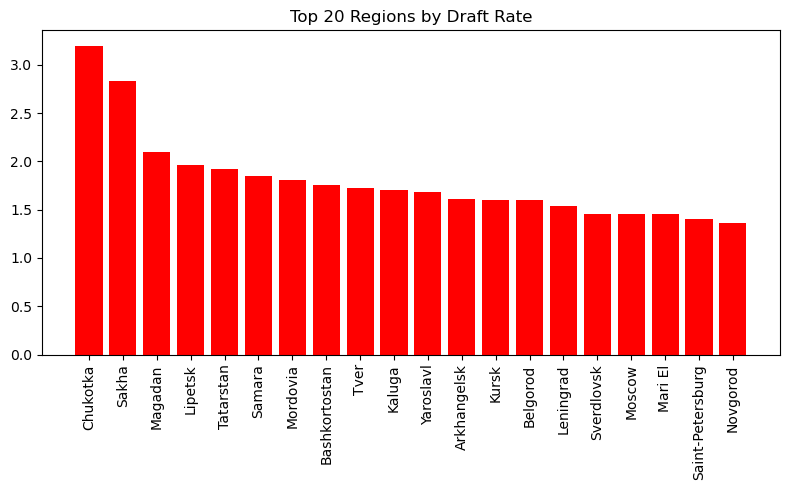

In [124]:
# Top regions
top_regions = df_stat.nlargest(20, 'draft_premium')
plt.figure(figsize=(8, 5))
plt.bar(top_regions['region'], top_regions['draft_premium'], color='red')
plt.title('Top 20 Regions by Draft Rate')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



In [128]:
model = smf.ols('draft_premium + urban_share + median_income + share_poverty +Q("% Russians")',
                 data=df_stat).fit()
print(model.summary())




PatsyError: Error evaluating factor: NameError: name 'share_poverty' is not defined
    draft_premium + urban_share + median_income + share_poverty +Q("% Russians")
                                                  ^^^^^^^^^^^^^

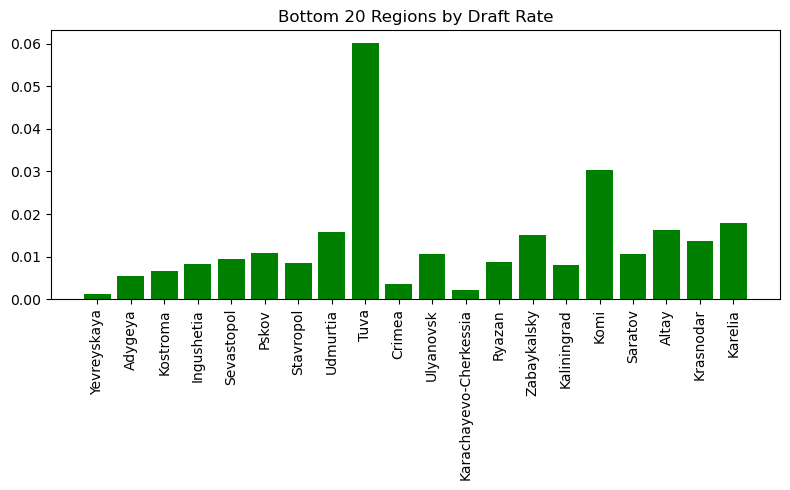

In [48]:
# Bottom regions  
bottom_regions = df_stat.nsmallest(20, 'draft_premium')
plt.figure(figsize=(8, 5))
plt.bar(bottom_regions['region'], bottom_regions['kia_rate'], color='green')
plt.title('Bottom 20 Regions by Draft Rate')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

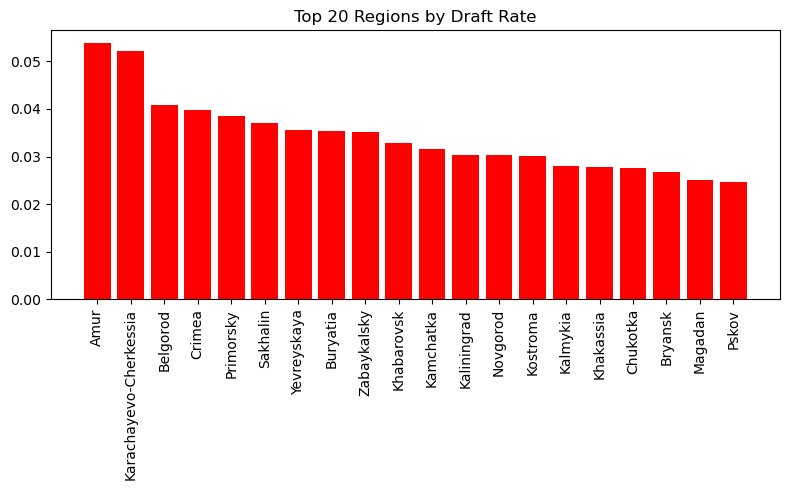

In [34]:
# Top regions
top_regions = df_stat.nlargest(20, 'draft_rate')
plt.figure(figsize=(8, 5))
plt.bar(top_regions['region'], top_regions['draft_rate'], color='red')
plt.title('Top 20 Regions by Draft Rate')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



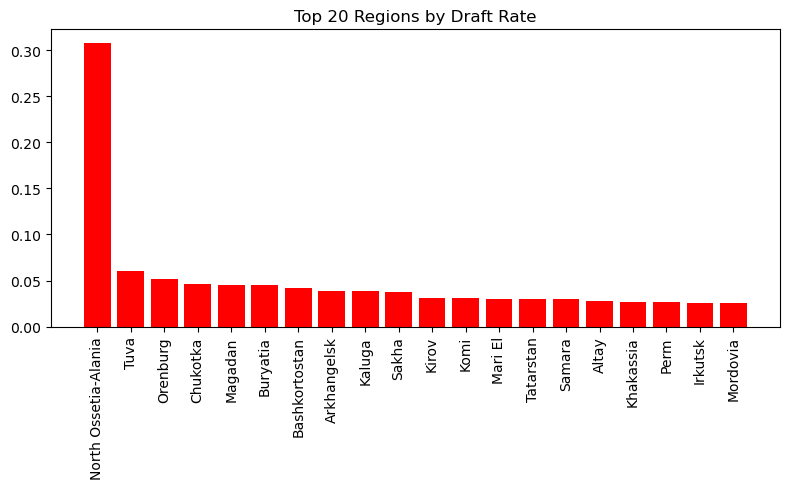

In [38]:
# Top regions
top_regions = df_stat.nlargest(20, 'kia_rate')
plt.figure(figsize=(8, 5))
plt.bar(top_regions['region'], top_regions['kia_rate'], color='red')
plt.title('Top 20 Regions by Draft Rate')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



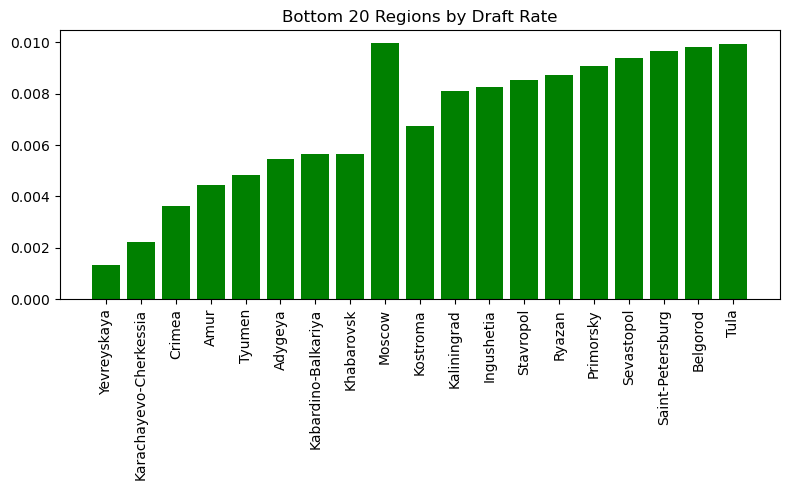

In [39]:
# Bottom regions  
bottom_regions = df_stat.nsmallest(20, 'kia_rate')
plt.figure(figsize=(8, 5))
plt.bar(bottom_regions['region'], bottom_regions['kia_rate'], color='green')
plt.title('Bottom 20 Regions by Draft Rate')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

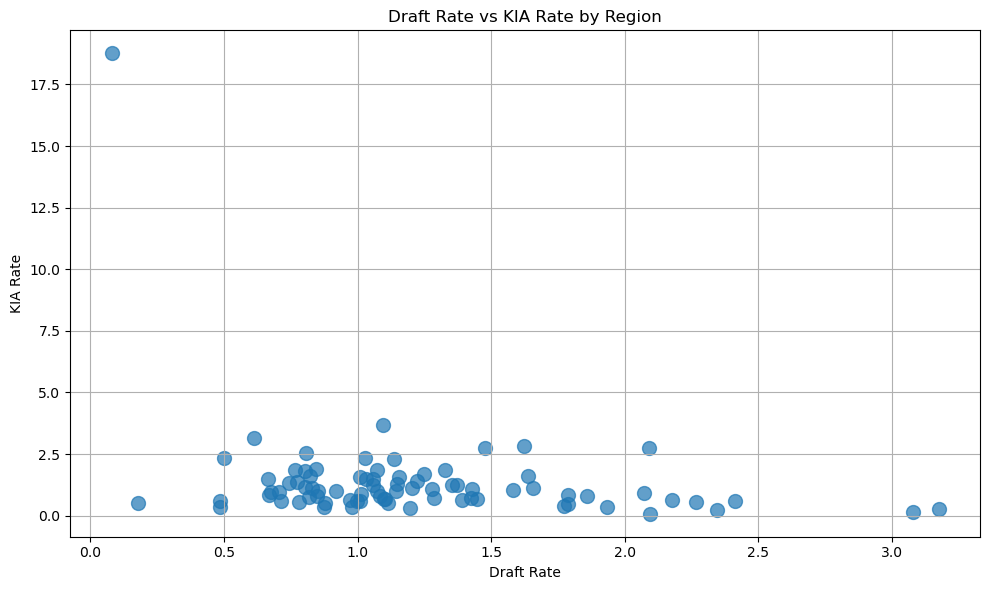

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(df_stat['rr_draft'], df_stat['rr_kia'], s=100, alpha=0.7)
plt.xlabel('Draft Rate')
plt.ylabel('KIA Rate')
plt.title('Draft Rate vs KIA Rate by Region')
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
df_stat['kia_rate'] = df_stat['cumsum_drafted'] / df_stat['mob_est']
overall_rate = df_stat['cumsum_drafted'].sum() / df_stat['mob_est'].sum()
df_stat['relative_risk'] = df_stat['kia_rate'] / overall_rate

# Show results sorted by risk
result = df_stat[['Region', 'kia_rate', 'relative_risk']].sort_values('relative_risk', ascending=False)
print(result)

                    Region  kia_rate  relative_risk
2791       Северная Осетия  0.307507      17.840826
2371       Республика Тыва  0.060164       3.490559
1573  Оренбургская область  0.051646       2.996387
3421          Чукотский АО  0.046220       2.681548
1195   Магаданская область  0.044789       2.598572
...                    ...       ...            ...
3337  Чеченская Республика -0.000122      -0.007099
1993   Республика Дагестан -0.021617      -1.254181
1363           Ненецкий АО       NaN            NaN
3253   Ханты-Мансийский АО       NaN            NaN
3505     Ямало-Hенецкий АО       NaN            NaN

[85 rows x 3 columns]


In [177]:
df_mob = df_post[['Region','Date', 'population', 'urban_share','uneployment', 'median_income','share_poverty',
                   '% Russians', 'insider', 'nat_rep', 'mob_est_per100k', 'mob_est']]
df_mob = df_mob[df_mob["Date"] == '2022-09-01'].drop_duplicates()
df_mob['log_pop'] = np.log(df_mob['population'])
df_mob

,Region,Date,population,urban_share,uneployment,median_income,share_poverty,% Russians,insider,nat_rep,mob_est_per100k,mob_est,log_pop
7,Алтайский край,2022-09-01,2142900.0,0.582787,3.7,24037.0,15.4,95.45,0.0,0.0,492.613174,10556.207710,14.577671
49,Амурская область,2022-09-01,759900.0,0.682661,4.2,34565.7,13.3,95.17,1.0,0.0,1572.719333,11951.094215,13.540942
91,Архангельская область без АО,2022-09-01,1010850.0,0.775789,5.6,35748.2,11.8,96.23,1.0,0.0,473.267832,4784.027877,13.826302
133,Астраханская область,2022-09-01,954200.0,0.641790,7.0,25038.0,13.8,67.10,0.0,0.0,368.624080,3517.410969,13.768629
175,Белгородская область,2022-09-01,1525500.0,0.653296,3.7,32811.0,6.1,95.29,0.0,0.0,1129.169241,17225.476773,14.237833
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3268,Челябинская область,2022-09-01,3414350.0,0.826057,3.1,27417.9,11.3,86.34,1.0,0.0,373.786372,12762.375008,15.043498
3352,Чувашская Республика,2022-09-01,1178550.0,0.641727,3.2,22320.9,14.8,30.70,1.0,1.0,339.410046,4000.117093,13.979795
3394,Чукотский АО,2022-09-01,47850.0,0.689656,1.9,82049.7,6.6,54.21,1.0,1.0,859.104616,411.081559,10.775826
3436,Якутия,2022-09-01,997700.0,0.670893,6.5,43912.2,15.5,32.63,1.0,1.0,555.658900,5543.808847,13.813208


In [176]:
model = smf.ols('mob_est_per100k ~  nat_rep + urban_share + share_poverty +Q("% Russians") + insider  + median_income',
                 data=df_mob).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        mob_est_per100k   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.167
Method:                 Least Squares   F-statistic:                     3.540
Date:                 Вс, 24 авг 2025   Prob (F-statistic):            0.00406
Time:                        18:25:55   Log-Likelihood:                -530.89
No. Observations:                  77   AIC:                             1076.
Df Residuals:                      70   BIC:                             1092.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         -45.6218    376.026     

In [178]:
model = smf.ols('mob_est ~ log_pop +  nat_rep + urban_share + share_poverty +Q("% Russians") + insider  + median_income',
                 data=df_mob).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                mob_est   R-squared:                       0.796
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     38.56
Date:                 Вс, 24 авг 2025   Prob (F-statistic):           1.95e-21
Time:                        18:28:53   Log-Likelihood:                -725.69
No. Observations:                  77   AIC:                             1467.
Df Residuals:                      69   BIC:                             1486.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept       -1.013e+05   9689.432    -

In [156]:
df_ord = df_post[['Region','Date', 'population', 'urban_share','uneployment', 'median_income',
       'av_income', 'share_poverty', '% Russians', '% Slavs', 'share_of_total',
       'share_of_income', 'insider', 'nat_rep', 'mob_est', 'first_kill', 'first_month_num']].dropna()
df_ord = df_ord[df_ord['first_kill'] == df_ord["Date"]]
df_ord

,Region,Date,population,urban_share,uneployment,median_income,av_income,share_poverty,% Russians,% Slavs,share_of_total,share_of_income,insider,nat_rep,mob_est,first_kill,first_month_num
13,Алтайский край,2023-03-01,2142900.0,0.582787,3.7,24037.0,31145.0,15.4,95.45,96.08,3.535321,21.405190,0.0,0.0,10556.207710,2023-03-01,7.0
57,Амурская область,2023-05-01,759900.0,0.682661,4.2,34565.7,44900.0,13.3,95.17,95.95,0.497311,4.365657,1.0,0.0,11951.094215,2023-05-01,8.0
94,Архангельская область без АО,2022-12-01,1010850.0,0.775789,5.6,35748.2,48356.0,11.8,96.23,97.06,1.255708,9.560010,1.0,0.0,4784.027877,2022-12-01,4.0
137,Астраханская область,2023-01-01,954200.0,0.641790,7.0,25038.0,31119.0,13.8,67.10,67.57,0.451990,6.106816,0.0,0.0,3517.410969,2023-01-01,5.0
176,Белгородская область,2022-10-01,1525500.0,0.653296,3.7,32811.0,41022.0,6.1,95.29,96.57,0.175462,1.063744,0.0,0.0,17225.476773,2022-10-01,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3269,Челябинская область,2022-10-01,3414350.0,0.826057,3.1,27417.9,33071.0,11.3,86.34,87.08,0.522170,1.793973,1.0,0.0,12762.375008,2022-10-01,2.0
3355,Чувашская Республика,2022-12-01,1178550.0,0.641727,3.2,22320.9,27213.0,14.8,30.70,30.96,1.789399,19.805901,1.0,1.0,4000.117093,2022-12-01,4.0
3399,Чукотский АО,2023-02-01,47850.0,0.689656,1.9,82049.7,114456.0,6.6,54.21,57.81,1.433430,29.321484,1.0,1.0,411.081559,2023-02-01,6.0
3438,Якутия,2022-11-01,997700.0,0.670893,6.5,43912.2,57715.0,15.5,32.63,33.58,6.160637,20.100487,1.0,1.0,5543.808847,2022-11-01,3.0


In [186]:
model = smf.ols('mob_kia_per100k ~ mob_est_per100k + nat_rep + urban_share + share_poverty +Q("% Russians") +' \
' C(Date) + insider + share_of_income + log_inc',
                 data=df_post[df_post["Date"] < "2025-01-01"]).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        mob_kia_per100k   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.424
Method:                 Least Squares   F-statistic:                     46.78
Date:                 Вс, 24 авг 2025   Prob (F-statistic):          1.17e-234
Time:                        18:39:31   Log-Likelihood:                -6524.7
No. Observations:                2176   AIC:                         1.312e+04
Df Residuals:                    2140   BIC:                         1.333e+04
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               -63.85

In [182]:
model = smf.ols('vol_kia_per100k ~ nat_rep + urban_share + share_poverty +Q("% Russians") +' \
' C(Date) + insider + share_of_income + median_income',
                 data=df_post[df_post["Date"] < "2025-01-01"]).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        vol_kia_per100k   R-squared:                       0.407
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     43.29
Date:                 Вс, 24 авг 2025   Prob (F-statistic):          5.37e-215
Time:                        18:36:57   Log-Likelihood:                -9577.1
No. Observations:                2176   AIC:                         1.922e+04
Df Residuals:                    2141   BIC:                         1.942e+04
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               -57.55